In [75]:
import numpy as np
from struct import unpack, pack
import matplotlib.pyplot as plt

In [76]:
P = 500
u1 = 4 
v1 = 5 
u2 = 5 
v2 = 4 # coefficients for embedding (4,5), (5,4)

In [77]:
marker_mapping = {
    0xffd8: "Start of Image",
    0xffe0: "Application Default Header",
    0xffdb: "Quantization Table",
    0xffc0: "Start of Frame",
    0xffc4: "Define Huffman Table",
    0xffda: "Start of Scan",
    0xffd9: "End of Image"
}

def GetArray(type, l, length):
    s = ""
    for i in range(length):
        s = s + type
    return list(unpack(s, l[:length]))

def RemoveFF00(data):
    datapro = []
    i = 0
    while True:
        b, bnext = unpack("BB", data[i:i+2])
        if b == 0xFF:
            if bnext !=0:
                break
            datapro.append(data[i])
            i+=2
        else:
            datapro.append(data[i])
            i += 1
    return datapro, i

def AddFF00(data):

    data_stuffed = []
    for byte in data:
        data_stuffed.append(byte)
        if byte == 0xFF:
            data_stuffed.append(0x00)
    data_stuffed.append(0xFF)
    data_stuffed.append(0xD9)
    return data_stuffed

# def AddFF00(data):
#     datapro = []
#     i = 0
#     while True:
#         b, bnext = unpack("BB", data[i:i+2])
#         datapro.append(data[i])
#         if b == 0xFF & bnext == 0xD9:
#             break
#         elif b == 0xFF & bnext != 0xD9:
#             datapro.append(0)
#         i+=1
#     return datapro


def DecodeNumber(code, bits):
    l = 2 ** (code -1)
    if bits >= l:
        return bits
    else:
        return bits - (2 * l -1)

def Clamp(col):
    """
    Makes sure col is between 0 and 255.
    """
    col = 255 if col > 255 else col
    col = 0 if col < 0 else col
    return int(col)

def ColorConversion(Y, Cb, Cr):
    R = np.zeros((8,8)).astype(np.uint8)
    G = np.zeros((8,8)).astype(np.uint8)
    B = np.zeros((8,8)).astype(np.uint8)
    for i in range(8):
        for j in range(8):
            R[i,j] = Clamp(Y.base[i][j] + (Cr.base[i][j]) * 1.402 +128)
            G[i,j] = Clamp(Y.base[i][j] - (Cb.base[i][j])*0.34414 - (Cr.base[i][j])*0.71414 + 128)
            B[i,j] = Clamp(Y.base[i][j] + (Cb.base[i][j]) * 1.772 + 128)
            # R[i,j] = Clamp((Cr.base[i][j] * (2 - 2 * 0.299) + Y.base[i][j])+128)
            # B[i,j] = Clamp((Cb.base[i][j] * (2 - 2 * 0.114) + Y.base[i][j])+128)
            # G[i,j] = Clamp(((Y.base[i][j] - 0.114 * B[i,j] - 0.299 * R[i,j]) / 0.587)+128)
    return R, G, B

def adjust_coeffs(block, bit):
    # print(block)
    k1 = block[u1, v1]
    k2 = block[u2, v2]
    # print(k1, k2, end='\n')
    # if bit == 1 |k1| >= |k2| + P
    # if bit == 0 |k2| >= |k1| + P
    if(bit == 1):
        if abs(k1) >= abs(k2) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = P+1
            new_k2 = 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg + P/2
            new_abs_k2 = avg - P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k1) < abs(new_k2) + P:
                new_k1 = (abs(new_k2) + P)*np.sign(new_k1)
    else:
        if abs(k2) >= abs(k1) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = 1
            new_k2 = P + 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg - P/2
            new_abs_k2 = avg + P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k2) < abs(new_k1) + P:
                new_k2 = (abs(new_k1) + P)*np.sign(new_k2)
    # print(new_k1, new_k2)
    block[u1, v1] = new_k1
    block[u2, v2] = new_k2
    # print(block[u1, v1])
    # print(block[u2, v2])
    return block

In [78]:
class LFSRGenerator:
    def __init__(self, seed, bits=16, taps = None):
        self.state = seed & ((1 << bits) - 1)
        self.bits = bits
        self.mask = (1 << bits) - 1
        # primitive polynome x^16 + x^14 + x^13 + x^11 + 1
        if taps == None:
            self.taps = [12, 6, 4, 1]#829
        else:
            self.taps = taps
        self.original_state = self.state

    def reset(self):
        self.state = self.original_state
    
    def next_bit(self):
        output = self.state & 1
        feedback = 0
        for tap in self.taps:
            feedback ^= (self.state >> (tap -1)) & 1

        self.state = (self.state << 1) | (feedback)# << (self.bits -1))
        self.state = self.state & self.mask
        # return output

    def get_bits(self, count):
        return [self.next_bit() for _ in range(count)]
    
    def get_int(self):
        self.next_bit()
        return self.state

In [79]:
class Stream:
    def __init__(self, data):
        self.data = bytearray(data)
        self.pos = 0
        self.current_byte = 0
        self.bits_in_current = 0

    def GetBit(self):
        b = self.data[self.pos >> 3]
        s = 7 - (self.pos & 0x7)
        self.pos += 1
        return (b >> s) & 1
    
    def PutBit(self, bit):
        self.current_byte = (self.current_byte << 1) | bit
        self.bits_in_current += 1
        self.pos += 1
        if self.bits_in_current == 8:
            self.data.append(self.current_byte)
            self.current_byte = 0
            self.bits_in_current = 0
    
    def PutBitN(self, value, N):
        for i in range(N -1, -1, -1):
            bit = (value >> i) & 1
            self.PutBit(bit)
    
    def GetBitN(self, l):
        val = 0
        for _ in range(l):
            val = val *2 + self.GetBit()
        return val
    
    def len(self):
        return len(self.data)
    

In [80]:
class HuffmanTable:
    def __init__(self):
        self.root = []
        self.elements = []
        # self.encode_dict = {}

    def BuildEncodeDict(self, node=None, current_code=0, current_len=0):
        if node is None:
            node = self.root
            self.encode_dict = {}
        
        if not isinstance(node, list):
            self.encode_dict[node] = (current_code, current_len)
        else:
            for i in range(len(node)):
                self.BuildEncodeDict(node[i], (current_code << 1) | i, current_len + 1)

    def GetCategoryAndBits(self, value):
        value = int(value)
        if value == 0:
            return 0, 0
        
        abs_val = abs(value)
        category = 0
        temp = abs_val
        while temp > 0:
            temp >>= 1
            category += 1

        if value > 0:
            bits = abs_val
        else:
            bits = (1 << category) - 1 - abs_val
        
        return category, bits

    def BitsFromLengths(self, root, element, pos):
        if isinstance(root, list):
            if pos == 0:
                if len(root) < 2:
                    root.append(element)
                    return True
                return False
            for i in [0, 1]:
                if len(root) == i:
                    root.append([])
                if self.BitsFromLengths(root[i], element, pos-1)== True:
                    return True
        return False

    def GetHuffmanBits(self, lengths, elements):
        self.elements = elements
        ii = 0
        for i in range(len(lengths)):
            for j in range(lengths[i]):
                self.BitsFromLengths(self.root, elements[ii], i)
                ii += 1

    def Find(self, st):
        r = self.root
        while isinstance(r, list):
            r = r[st.GetBit()]
        return r

    def GetCode(self, st):
        while True:
            res = self.Find(st)
            if res == 0:
                return 0
            elif res != -1:
                return res


In [81]:
class IDCT:
    def __init__(self):
        self.base = [0] *64
        self.zigzag = [
            [0, 1, 5, 6, 14, 15, 27, 28],
            [2, 4, 7, 13, 16, 26, 29, 42],
            [3, 8, 12, 17, 25, 30, 41, 43],
            [9, 11, 18, 24, 31, 40, 44, 53],
            [10, 19, 23, 32, 39, 45, 52, 54],
            [20, 22, 33, 38, 46, 51, 55, 60],
            [21, 34, 37, 47, 50, 56, 59, 61],
            [35, 36, 48, 49, 57, 58, 62, 63],
        ]
        
        self.idct_precision = 8
        self.idct_table = [
            [
                (self.NormCoeff(u)*np.cos(((2*x+1) * u * np.pi)/16))
                for x in range(self.idct_precision)
            ]
            for u in range(self.idct_precision)
        ]
    
    def NormCoeff(self, n):
        if n == 0:
            return 1/np.sqrt(2)
        else:
            return 1
        
    def rearrange_using_zigzag(self):
        for x in range(8):
            for y in range(8):
                self.zigzag[x][y] = self.base[self.zigzag[x][y]]

    def perform_IDCT(self):
        out = [list(range(8)) for i in range(8)]

        for x in range(8):
            for y in range(8):
                local_sum = 0
                for u in range(self.idct_precision):
                    for v in range(self.idct_precision):
                        local_sum += (self.zigzag[v][u] * self.idct_table[u][x] * self.idct_table[v][y])
                out[y][x] = local_sum // 4
        self.base = out

Start of Image
Application Default Header
None
Quantization Table
Quantization Table
Start of Frame
Define Huffman Table
0 0 0
[0, 2, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[5, 6, 4, 7, 8, 3, 1, 0]
{5: (0, 2), 6: (1, 2), 4: (4, 3), 7: (5, 3), 8: (6, 3), 3: (14, 4), 1: (30, 5), 0: (62, 6)}
Define Huffman Table
16 0 1
[0, 2, 2, 2, 2, 1, 4, 1, 4, 2, 2, 3, 0, 0, 0, 0]
[1, 2, 3, 4, 5, 17, 6, 18, 33, 0, 7, 19, 34, 49, 20, 50, 65, 81, 21, 35, 66, 97, 8, 129, 145]
{1: (0, 2), 2: (1, 2), 3: (4, 3), 4: (5, 3), 5: (12, 4), 17: (13, 4), 6: (28, 5), 18: (29, 5), 33: (60, 6), 0: (122, 7), 7: (123, 7), 19: (124, 7), 34: (125, 7), 49: (252, 8), 20: (506, 9), 50: (507, 9), 65: (508, 9), 81: (509, 9), 21: (1020, 10), 35: (1021, 10), 66: (2044, 11), 97: (2045, 11), 8: (4092, 12), 129: (4093, 12), 145: (4094, 12)}
Define Huffman Table
1 1 0
[0, 2, 2, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[5, 6, 4, 7, 1, 3, 8, 2]
{5: (0, 2), 6: (1, 2), 4: (4, 3), 7: (5, 3), 1: (12, 4), 3: (13, 4), 8: (14, 4), 2: (30, 5

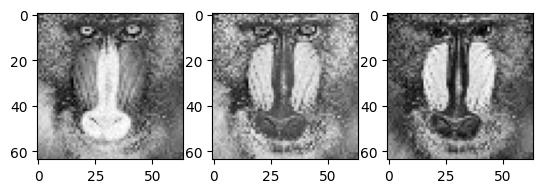

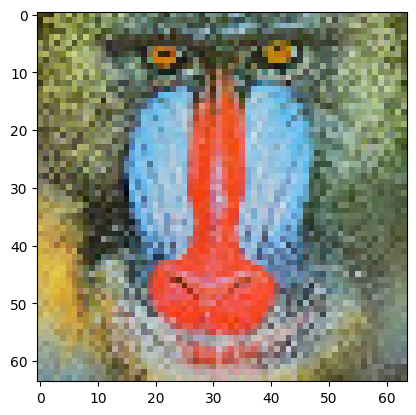

In [88]:
class JPEG:
    def __init__(self, image_file, message):
        self.huffman_tables = {}
        self.quant = {}
        self.quantMapping = []
        self.binary_message = ''.join(format(ord(char), '08b') for char in message)
        self.binary_message += '00000000'
        self.pos = 0
        with open(image_file, 'rb') as f:
            self.img_data = f.read()
    
    def DefineQuantizationTables(self, data):
        hdr, = unpack("B", data[0:1])
        self.quant[hdr] = GetArray("B", data[1:1+64], 64)
        data = data[65:]

    def BuildMatrix(self, st, idx, quant, olddccoef):
        i = IDCT()
        code = self.huffman_tables[0+idx].GetCode(st)
        bits = st.GetBitN(code)
        dccoef = DecodeNumber(code, bits) + olddccoef

        i.base[0] = (dccoef) * quant[0]
        l = 1
        while l < 64:
            code = self.huffman_tables[16 + idx].GetCode(st)
            if code == 0:
                break

            if code > 15:
                l += code >> 4
                code = code & 0x0F
            bits = st.GetBitN(code)
            if l < 64:
                coeff = DecodeNumber(code, bits)
                i.base[l] = coeff * quant[l]
                l += 1
        i.rearrange_using_zigzag()
        # i.perform_IDCT()
        return i, dccoef

    def decodeHuffman(self, data):
        offset = 0
        header, = unpack("B", data[offset:offset+1])
        print(header, header & 0x0F, (header >> 4) & 0x0F)
        offset +=1
        lengths = GetArray("B", data[offset:offset+16], 16)
        offset += 16
        elements = []
        for i in lengths:
            elements += GetArray("B", data[offset:offset+i],i)
            offset += i
        hf = HuffmanTable()
        print(lengths)
        print(elements)
        hf.GetHuffmanBits(lengths, elements)
        hf.BuildEncodeDict()
        print(hf.encode_dict)
        self.huffman_tables[header] = hf
        data = data[offset:]

    def StartOfScan(self, data, hdrlen):
        self.dct_image = np.zeros((self.height, self.width, 3))#.astype(np.uint8)
        data, lenchunk = RemoveFF00(data[hdrlen:])
        st = Stream(data)
        oldlumdc, oldcbdc, oldcrdc = 0, 0, 0
        for y in range(self.height // 8):
            for x in range(self.width // 8):
                matL, oldlumdc = self.BuildMatrix(st, 0, self.quant[self.quantMapping[0]], oldlumdc)
                matCb, oldcbdc = self.BuildMatrix(st, 1, self.quant[self.quantMapping[1]], oldcbdc)
                matCr, oldcrdc = self.BuildMatrix(st, 1, self.quant[self.quantMapping[2]], oldcrdc)
                # R, G, B = ColorConversion(matL, matCb, matCr)
                
                self.dct_image[y*8:y*8+8,x*8:x*8+8,0] = matL.zigzag
                self.dct_image[y*8:y*8+8,x*8:x*8+8,1] = matCb.zigzag
                self.dct_image[y*8:y*8+8,x*8:x*8+8,2] = matCr.zigzag
        return lenchunk+hdrlen
    
    def BaselineDCT(self, data):
        hdr, self.height, self.width, components = unpack(">BHHB", data[0:6])
        for i in range(components):
            id, samp, QtbId = unpack("BBB", data[6 + i*3:9+i*3])
            self.quantMapping.append(QtbId)

    def decode(self):
        data = self.img_data
        self.img_data = bytearray(self.img_data)
        # pos = 0
        while(True):
            marker, = unpack(">H", data[0:2])
            print(marker_mapping.get(marker))
            if marker == 0xffd8:
                data = data[2:]
                self.pos += 2
            elif marker == 0xffd9:
                return
            else:
                lenchunk, = unpack(">H", data[2:4])
                lenchunk += 2
                self.pos += lenchunk
                chunk = data[4:lenchunk]
                if marker == 0xffc4:
                    self.decodeHuffman(chunk)
                elif marker == 0xffdb:
                    self.DefineQuantizationTables(chunk)
                elif marker == 0xffc0:
                    self.BaselineDCT(chunk)
                elif marker == 0xffda:
                    lenchunk = self.StartOfScan(data, lenchunk)
                    
                    self.img_data[self.pos:] = pack("BB", 0xFF, 0xD9)
                    # self.img_data[pos:pos+2] = 0xFFD9

                
                data = data[lenchunk:]  

            if len(data)==0:
                break   
    
    def embeddeMessage(self):
        bit_index = 0
        lfsr = LFSRGenerator(seed=0xFD2A, bits=12)
        lfsr.reset()

        for i in range(len(self.binary_message)):
            block_index = lfsr.get_int()
            row = int(block_index // (self.dct_image.shape[0]/8))
            col = int(block_index % (self.dct_image.shape[1]/8))
            # print(row, col)
            block = self.dct_image[row*8:(row+1)*8, col*8:(col+1)*8, 0]
            current_bit = int(self.binary_message[bit_index])
            # print(block[u1, v1], block[u2, v2])
            # print(block)
            self.dct_image[row*8:(row+1)*8, col*8:(col+1)*8,0] = adjust_coeffs(block, current_bit)
            bit_index += 1
            # print(block[u1, v1], block[u2, v2])

    def encodeBlock(self, block, olddccoef, idx, quant, st):
        matr = IDCT()
        for i in range(8):
            for j in range(8):
                matr.base[matr.zigzag[i][j]] = int(block[i,j] / quant[matr.zigzag[i][j]])
        # print(matr.base)
        dccoef = matr.base[0]
        diff = dccoef - olddccoef
        category, bits = self.huffman_tables[0+idx].GetCategoryAndBits(diff)

        huff_code, huff_len = self.huffman_tables[0+idx].encode_dict[category]
        # print(st)
        st.PutBitN(huff_code, huff_len)
        if category > 0:
            st.PutBitN(bits, category)

        run_length = 0
        for i in range(1, 64):
            val = matr.base[i]
            if val == 0:
                run_length += 1
            else:
                while run_length > 15:
                    zrl_code, zrl_len = self.huffman_tables[16+idx].encode_dict[0xF0]
                    st.PutBitN(zrl_code, zrl_len)
                    run_length -= 16
                category, bits = self.huffman_tables[16+idx].GetCategoryAndBits(val)
                symbol = (run_length << 4) | category
                # print(symbol)
                huff_code, huff_len = self.huffman_tables[16+idx].encode_dict[symbol]
                st.PutBitN(huff_code, huff_len)
                st.PutBitN(bits, category)
                run_length = 0
        if run_length > 0:
            eob_code, eob_len = self.huffman_tables[16+idx].encode_dict[0x00]
            st.PutBitN(eob_code, eob_len)

        return dccoef
        
                


    def encodeSOS(self, data):
        st = Stream(data)
        # matL = IDCT()
        # matCb = IDCT()
        # matCr = IDCT()
        olddcL, olddcCb, olddcCr = 0, 0, 0
        for i in range(self.height//8):
            for j in range(self.width//8):
                blockL = self.dct_image[i*8:i*8+8, j*8:j*8+8, 0]
                blockCb = self.dct_image[i*8:i*8+8, j*8:j*8+8, 1]
                blockCr = self.dct_image[i*8:i*8+8, j*8:j*8+8, 2]
                olddcL = self.encodeBlock(blockL, olddcL, 0, self.quant[self.quantMapping[0]], st)
                olddcCb = self.encodeBlock(blockCb, olddcCb, 1, self.quant[self.quantMapping[1]], st)
                olddcCr = self.encodeBlock(blockCr, olddcCr, 1, self.quant[self.quantMapping[2]], st)
        st.PutBitN(0xFFD9, 16)
        data = AddFF00(st.data)
        return data


    def calc_IDCT(self):
        self.image = np.zeros((self.height, self.width, 3)).astype(np.uint8)
        matL= IDCT()
        matCb = IDCT()
        matCr = IDCT()
        for y in range(self.height // 8):
            for x in range(self.width // 8):
                matL.zigzag = self.dct_image[y*8:y*8+8,x*8:x*8+8,0]
                matCb.zigzag = self.dct_image[y*8:y*8+8,x*8:x*8+8,1]
                matCr.zigzag = self.dct_image[y*8:y*8+8,x*8:x*8+8,2] 
                matL.perform_IDCT()
                matCb.perform_IDCT()
                matCr.perform_IDCT()
                R, G, B = ColorConversion(matL, matCb, matCr)
                self.image[y*8:y*8+8,x*8:x*8+8,0] = R#matL.base
                self.image[y*8:y*8+8,x*8:x*8+8,1] = G#matCb.base
                self.image[y*8:y*8+8,x*8:x*8+8,2] = B#matCr.base

    def encode(self):
        # data = self.img_data
        # self.img_data = bytearray(self.img_data)   # теперь это изменяемый массив байт
        new_data = bytearray()
        st = Stream(new_data)
        olddcL, olddcCb, olddcCr = 0, 0, 0
        for i in range(self.height//8):
            for j in range(self.width//8):
                blockL = self.dct_image[i*8:i*8+8, j*8:j*8+8, 0]
                blockCb = self.dct_image[i*8:i*8+8, j*8:j*8+8, 1]
                blockCr = self.dct_image[i*8:i*8+8, j*8:j*8+8, 2]
                olddcL = self.encodeBlock(blockL, olddcL, 0, self.quant[self.quantMapping[0]], st)
                olddcCb = self.encodeBlock(blockCb, olddcCb, 1, self.quant[self.quantMapping[1]], st)
                olddcCr = self.encodeBlock(blockCr, olddcCr, 1, self.quant[self.quantMapping[2]], st)
        # st.PutBitN(0xFFD9, 16)
        new_data = AddFF00(st.data)

        # pos = 0
        self.img_data[self.pos:] = new_data
        # self.pos +=6
        # self.img_data[self.pos:] = pack("BB", 0xFF, 0xD9)
        # while(True):
        #     marker, = unpack(">H", data[0:2])
        #     print(marker_mapping.get(marker))
        #     if marker == 0xffd8:
        #         data = data[2:]
        #     elif marker == 0xffd9:
        #         return
        #     else:
        #         lenchunk, = unpack(">H", data[2:4])
        #         lenchunk += 2
        #         pos += lenchunk
        #         chunk = data[4:lenchunk]

        #         # if marker == 0xffc4:
        #         #     self.decodeHuffman(chunk)
        #         # elif marker == 0xffdb:
        #         #     self.DefineQuantizationTables(chunk)
        #         # elif marker == 0xffc0:
        #         #     self.BaselineDCT(chunk)
        #         if marker == 0xffda:
        #             # lenchunk = self.StartOfScan(data, lenchunk)
        #             # data = data[64:]
        #             new_data = self.encodeSOS(new_data)
        #             self.img_data[pos:] = new_data
        #             # self.img_data[pos+128:pos+132] = pack("BBBB", 34, 1, 120, 50)
                
        #         data = data[lenchunk:]  
                
        #     if len(data)==0:
        #         break

    def save(self):
        with open("stego_image.jpg", 'wb') as f:
            f.write(self.img_data)

if __name__ == "__main__":
    img = JPEG('baboon64.jpg', "Hello, my name is Sergey!")
    img.decode()
    # img.embeddeMessage() 
    img.calc_IDCT()
    img.encode()
    img.save()
    print(img.image[0,0])
    plt.figure()
    plt.subplot(1, 3, 1)
    plt.imshow(img.image[:,:,0], cmap="gray")
    plt.subplot(1, 3, 2)
    plt.imshow(img.image[:,:,1], cmap="gray")
    plt.subplot(1, 3, 3)
    plt.imshow(img.image[:,:,2], cmap="gray")
    # plt.subplot(1, 4, 4)
    plt.figure()
    plt.imshow(img.image)